# **Final XGBoost Model, Threshold Optimization & Feature Importance Analysis**

Tuned XGBoost using RandomizedSearchCV, performed leakage-safe threshold selection via cross-validated predictions, and evaluated final model performance using ROC-AUC and PR-AUC.

Also analysed feature importance and SHAP interpretability to ensure that the features that are given high importance are in tune with real life scenarios, and check how they influence probability of default.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score, average_precision_score, precision_recall_curve, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_predict
import shap
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
application_train = pd.read_csv('/content/drive/MyDrive/Credit_default_model_dataset/HC_application_train.csv')
application_train.drop(columns=['SK_ID_CURR'], inplace=True)

null_threshold = 0.6
processed_df = application_train.loc[:,application_train.isnull().mean()<0.6]

obj_cols = processed_df.select_dtypes(include='object').columns
for cols in obj_cols:
  processed_df[cols] = processed_df[cols].fillna(processed_df[cols].mode()[0])

num_cols = processed_df.select_dtypes(include=['int64','float64']).columns
for cols in num_cols:
  processed_df[cols]=processed_df[cols].fillna(processed_df[cols].median())

le = LabelEncoder()
for cols in obj_cols:
  processed_df[cols] = le.fit_transform(processed_df[cols])

X = processed_df.drop(columns='TARGET')
Y = processed_df['TARGET']

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify = Y)

In [4]:
param_grid = {'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

**Hyperparameter tuning**

In [5]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
search = RandomizedSearchCV(xgb, param_grid, n_iter=20, scoring='roc_auc', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), verbose=1, n_jobs=-1, random_state=42)

In [6]:
search.fit(X_train, Y_train)

best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


**Threshold selection using cross validation**

In [7]:
y_train_prob = cross_val_predict(best_model, X_train, Y_train, cv=5, method="predict_proba")[:, 1]

In [8]:
precision, recall, thresholds = precision_recall_curve(Y_train, y_train_prob)

In [9]:
f1_score = 2*(precision*recall)/(precision + recall + 1e-8)

In [10]:
max_f1_index = np.argmax(f1_score==max(f1_score))
best_threshold = thresholds[max_f1_index]

**Prediction based on selected threshold**

In [11]:
y_test_prob = best_model.predict_proba(X_test)[:,1]

In [12]:
y_test_pred = (y_test_prob >= best_threshold).astype(int)

**Performance metrics**

Final Test ROC-AUC: 0.7604562761075735

Final Test PR-AUC: 0.25089096006469946

Confusion Matrix:
[[50676  5862]
 [ 2982  1983]]


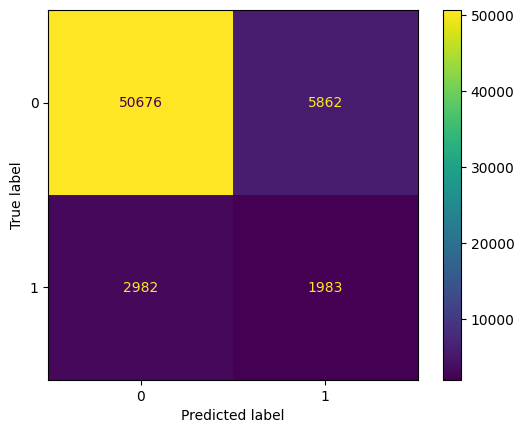


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     56538
           1       0.25      0.40      0.31      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.65      0.61     61503
weighted avg       0.89      0.86      0.87     61503



In [13]:
print("Final Test ROC-AUC:", roc_auc_score(Y_test, y_test_prob))
print("\nFinal Test PR-AUC:", average_precision_score(Y_test, y_test_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_test_pred))
disp_cm = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(Y_test, y_test_pred))
disp_cm.plot()
plt.show()

print("\nClassification Report:")
print(classification_report(Y_test, y_test_pred))

In [14]:
print("Cross Validation ROC-AUC:", roc_auc_score(Y_train, y_train_prob))
print("\nCross Validation PR-AUC:", average_precision_score(Y_train, y_train_prob))

Cross Validation ROC-AUC: 0.7564996468015376

Cross Validation PR-AUC: 0.23923661365889792


# **Feature Importance**

In [15]:
feature_importance = best_model.feature_importances_
feature_importance_df = pd.DataFrame({"Feature": X_train.columns, "Importance": feature_importance,}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
39,EXT_SOURCE_2,0.133748
40,EXT_SOURCE_3,0.089664
10,NAME_INCOME_TYPE,0.051761
78,FLAG_DOCUMENT_3,0.046519
1,CODE_GENDER,0.046458
11,NAME_EDUCATION_TYPE,0.045553
44,ELEVATORS_AVG,0.036067
38,EXT_SOURCE_1,0.027418
2,FLAG_OWN_CAR,0.023327
8,AMT_GOODS_PRICE,0.018840


**SHAP Interpretation**

In [16]:
interpretor = shap.TreeExplainer(best_model)
shap_values = interpretor.shap_values(X_test)

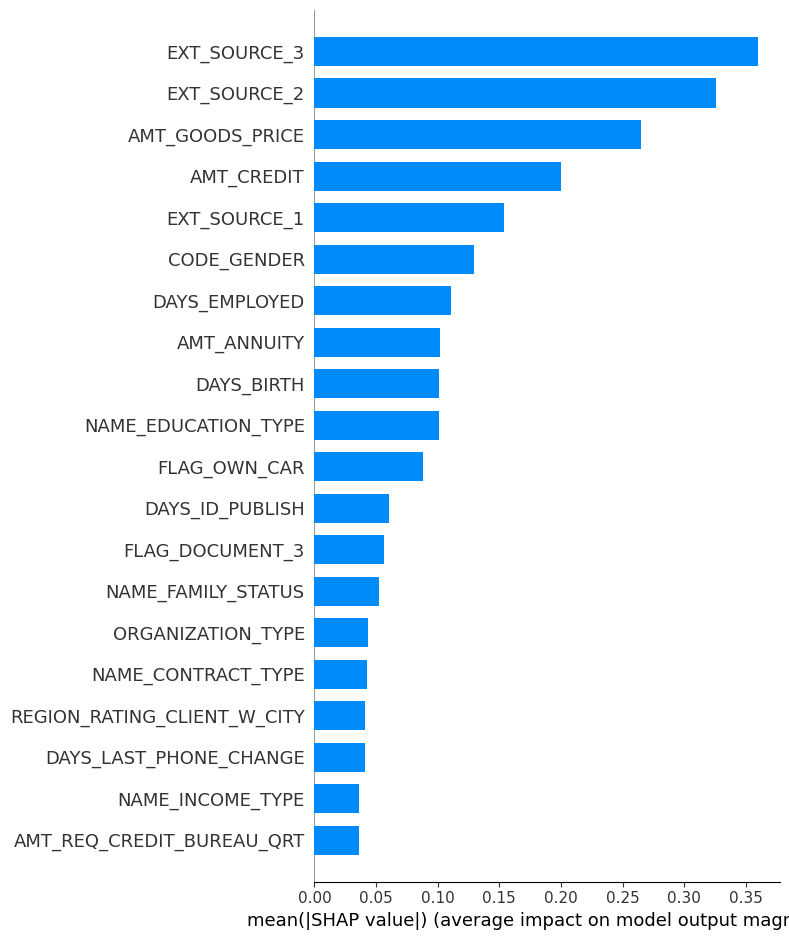

In [17]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

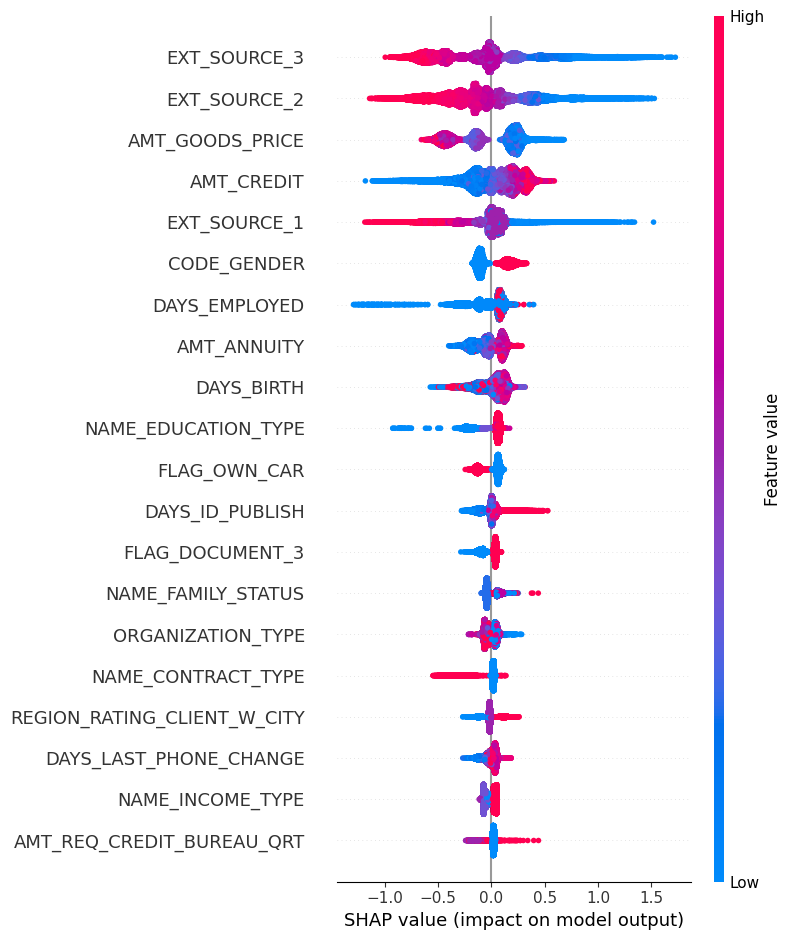

In [18]:
shap.summary_plot(shap_values,X_test)